# Financial Sentiment Analysis — RNN, LSTM & Word2Vec

This notebook trains and evaluates three deep learning models on the **Financial PhraseBank** dataset:

Model : Embedding

Simple RNN : Trainable (64-d)

LSTM : Trainable (64-d) + L2

LSTM + Word2Vec : Frozen Word2Vec (100-d)

A **Gradio GUI** is provided at the end for real-time prediction.

---

## Notebook Structure
Description

Install & import libraries

Load and inspect dataset

Text preprocessing

Tokenization, padding, train/val/test split

Model building and training

Evaluation and comparison

Gradio GUI for real-time prediction

---

## 1. Setup

### 1.1 Install Required Libraries

In [1]:
!pip install contractions wordcloud gensim gradio nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00


### 1.2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
import nltk

# NLP utilities
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Scikit-learn: splitting, encoding, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Keras: tokenizer, padding, model layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# Word2Vec embeddings
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

### 1.3 Download NLTK Resources

In [3]:
nltk.download('stopwords')  # English stop word list
nltk.download('wordnet')    # Lemmatization dictionary
nltk.download('omw-1.4')   # Open Multilingual Wordnet (required by WordNetLemmatizer)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

---

## 2. Load Dataset

The cell below tries Google Drive first; if the file is not found it falls back to a manual Colab upload.

> **Expected columns:** `text` (financial sentence) and `label` (positive / neutral / negative)

In [4]:
import os

# Try loading from Google Drive; add more paths here if needed
possible_paths = [
    "/content/drive/MyDrive/AL ML/Assignment/financial_phrase.csv",
    "/content/financial_phrase.csv"
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

# Fallback: manual upload prompt in Colab
if DATA_PATH is None:
    try:
        from google.colab import files
        print("Please upload financial_phrase.csv")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "financial_phrase.csv not found. Please upload the CSV file."
        ) from e

df = pd.read_csv(DATA_PATH)

# Normalise column names: strip whitespace and lowercase
df.columns = [col.strip().lower() for col in df.columns]

# Validate required columns
if 'text' not in df.columns or 'label' not in df.columns:
    print('Current columns:', df.columns.tolist())
    raise ValueError("Dataset must contain 'text' and 'label' columns.")

print('Dataset loaded from:', DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Please upload financial_phrase.csv


Saving financial_phrase.csv to financial_phrase.csv
Dataset loaded from: financial_phrase.csv
Shape: (2264, 2)


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


### 2.1 Dataset Information

In [5]:
# Column names and label distribution — check for class imbalance
print('Columns:', df.columns.tolist())
print()
print('Label distribution:')
print(df['label'].value_counts())

Columns: ['text', 'label']

Label distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


---

## 3. Text Preprocessing

Each raw sentence passes through the following pipeline:

1. **Lowercase** — normalises casing
2. **Expand contractions** — e.g. *don't* → *do not*
3. **Remove URLs, mentions, hashtags**
4. **Remove numbers**
5. **Remove special characters**
6. **Stopword removal**
7. **Lemmatization** — reduce to base form (e.g. *running* → *run*)

In [6]:
# Initialise once — reused inside clean_text for every row
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """Full preprocessing pipeline for a single financial sentence."""

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand contractions (e.g. "won't" → "will not")
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 4: Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 5: Remove standalone digit sequences
    text = re.sub(r'\d+', '', text)

    # Step 6: Keep only alphabetic characters and whitespace
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 7: Split into tokens
    words = text.split()

    # Step 8: Remove stopwords and lemmatize each remaining token
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

### 3.1 Apply Preprocessing

In [7]:
# Apply the cleaning pipeline to every row; store in a new column
df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  According to Gran , the company has no plans t...   
1  For the last quarter of 2010 , Componenta 's n...   
2  In the third quarter of 2010 , net sales incre...   
3  Operating profit rose to EUR 13.1 mn from EUR ...   
4  Operating profit totalled EUR 21.1 mn , up fro...   

                                          clean_text  
0  according gran company plan move production ru...  
1  last quarter componenta net sale doubled eurm ...  
2  third quarter net sale increased eur mn operat...  
3  operating profit rose eur mn eur mn correspond...  
4  operating profit totalled eur mn eur mn repres...  


### 3.2 Word Cloud of Cleaned Text

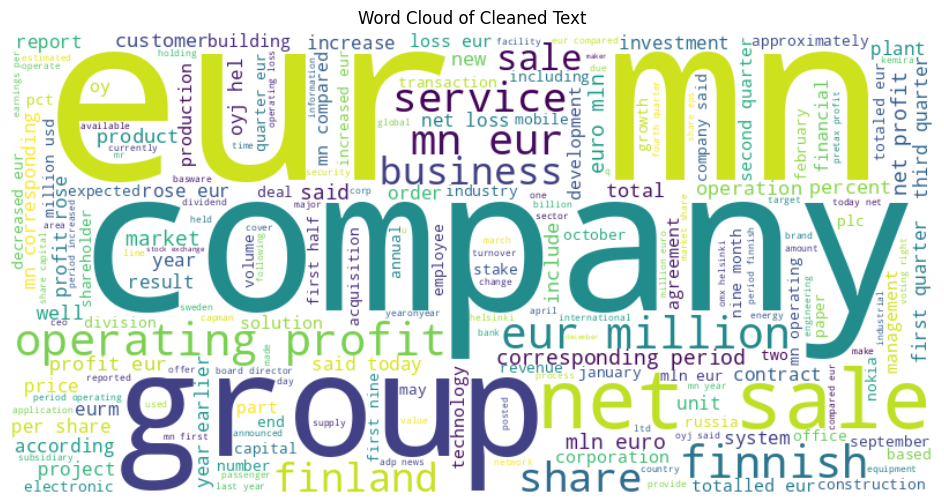

In [8]:
# Join all cleaned tokens into one string for the word cloud generator
all_words = ' '.join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text')
plt.show()

### 3.3 Top 20 Most Frequent Words

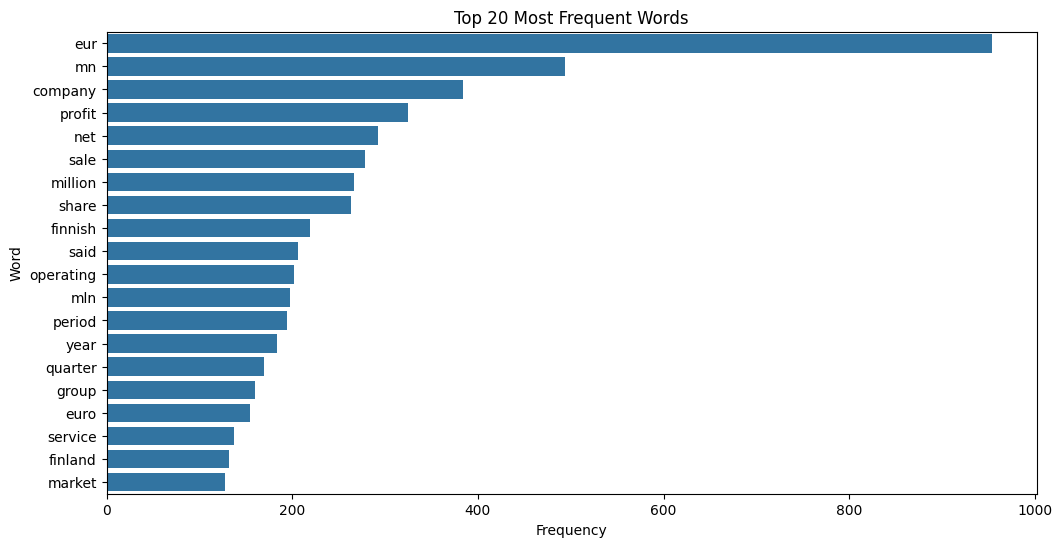

In [9]:
from collections import Counter

all_tokens   = ' '.join(df['clean_text']).split()
word_freq    = Counter(all_tokens)
common_words = word_freq.most_common(20)

freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=freq_df)
plt.title('Top 20 Most Frequent Words')
plt.show()

---

## 4. Label Encoding and Data Splitting

### 4.1 Encode Target Labels

Convert string labels (`positive`, `neutral`, `negative`) to integers.

In [10]:
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])

# Show the class → integer mapping
print('Label mapping:', dict(zip(label_encoder.classes_,
                                  label_encoder.transform(label_encoder.classes_))))

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


### 4.2 Train / Validation / Test Split

> **Fix applied:** The original used `validation_split=0.2` inside `model.fit()`,
> which Keras handles by taking the **last 20% of rows without shuffling**.
> EarlyStopping then monitors the same fixed slice every run — a subtle selection bias.
>
> **Solution:** Create an explicit, stratified validation set before training.

Split : Proportion

Train : 64%

Validation : 16%

Test : 20%

In [11]:
X = df['clean_text']
y = df['encoded_label']

# Split 1: 80% train+val, 20% held-out test
# stratify=y preserves class proportions in both halves
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split 2: 80% of train+val → train, 20% → explicit validation
# This replaces validation_split inside model.fit()
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f'Train      : {X_train.shape[0]} samples')
print(f'Validation : {X_val.shape[0]} samples')
print(f'Test       : {X_test.shape[0]} samples')

Train      : 1448 samples
Validation : 363 samples
Test       : 453 samples


### 4.3 Fit Tokenizer on Training Data Only

> **Fix applied:** `vocab_size` is now computed dynamically after fitting so the
> Embedding `input_dim` always matches the actual vocabulary — no wasted rows,
> no silent OOV for tokens above the cap.

In [12]:
# Tokenizer maps words to integers; <OOV> handles words unseen at inference
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Fit ONLY on training data to prevent test-set vocabulary leakage
tokenizer.fit_on_texts(X_train)

# Dynamically cap vocab_size to the actual vocabulary
vocab_size = min(10000, len(tokenizer.word_index) + 1)
print('Effective vocabulary size:', vocab_size)

Effective vocabulary size: 3914


### 4.4 Convert Text to Padded Sequences

In [13]:
# Convert each sentence to a list of token IDs
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Use 95th percentile of training lengths as max_length
# — covers most sentences without padding to extreme outliers
sequence_lengths = [len(seq) for seq in X_train_seq]
max_length = int(np.percentile(sequence_lengths, 95))
print('Padded sequence length (95th pct):', max_length)

# Pad / truncate all splits to max_length with post-padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_length, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post')

Padded sequence length (95th pct): 22


---

## 5. Model Building and Training

| Model | Embedding dim | Recurrent units | Regularization |
|-------|--------------|-----------------|----------------|
| Simple RNN | 64 | 64 | dropout + recurrent_dropout inside RNN |
| LSTM | 64 | 64 | dropout + recurrent_dropout inside LSTM + L2 on Dense |
| Word2Vec LSTM | 100 (frozen) | 64 | dropout + recurrent_dropout inside LSTM |

> **Key fix for all models:** A **fresh `EarlyStopping`** instance is created before each
> `model.fit()`. Keras callbacks are stateful — reusing one object carries over the wait
> counter and best weights from the previous model, corrupting early stopping for all
> subsequent models.

### 5.1 Model 1 — Simple RNN with Trainable Embedding

> **Fix applied:** Original used standalone `Dropout(0.7)` after the RNN output.
> 70% dropout is far too aggressive for 64 units and misses the recurrent connections
> (where sequence models actually overfit). `recurrent_dropout` inside the layer is more
> effective. Embedding dim reduced 128 → 64 (rule of thumb: vocab_size ^ 0.25 ≈ 56).

In [14]:
# Embedding dim: vocab_size^0.25 ≈ 56 — 64 is a practical round number
embedding_dim = 64

model_rnn = Sequential([

    # Embedding: maps token IDs to dense vectors; input_dim uses dynamic vocab_size
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_length,)),

    # SimpleRNN with internal dropout:
    #   dropout           — applied to input-to-hidden connections
    #   recurrent_dropout — applied to hidden-to-hidden (recurrent) connections
    # More effective than a separate Dropout layer placed after the RNN output
    SimpleRNN(64, dropout=0.3, recurrent_dropout=0.2, return_sequences=False),

    # Additional regularization on the classifier head
    Dropout(0.3),
    Dense(32, activation='relu'),

    # 3 units — one per class (positive / neutral / negative)
    Dense(3, activation='softmax')
], name='SimpleRNN_Model')

model_rnn.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 22, 64)         │       250,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,931 (1019.26 KB)

 Trainable params: 260,931 (1019.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',  # integer labels, not one-hot
    optimizer='adam',
    metrics=['accuracy']
)

# Fresh EarlyStopping — never reuse the same instance across models
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),  # explicit val set (not validation_split)
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_rnn]
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4461 - loss: 1.0634 - val_accuracy: 0.6143 - val_loss: 0.9216
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6112 - loss: 0.9330 - val_accuracy: 0.6143 - val_loss: 0.9134
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6133 - loss: 0.9359 - val_accuracy: 0.6143 - val_loss: 0.9116
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6105 - loss: 0.9302 - val_accuracy: 0.6143 - val_loss: 0.8926
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6195 - loss: 0.9011 - val_accuracy: 0.6391 - val_loss: 0.8095
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6402 - loss: 0.8391 - val_accuracy: 0.7080 - val_loss: 0.7236
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6878 - loss: 0.7255 - val_accuracy: 0.6501 - val_loss: 0.8070
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7403 - loss: 0.6578 - val_accuracy: 0.6997 - v

### 5.2 Model 2 — LSTM with Trainable Embedding

> **Fix applied:** Original applied L2 to both Dense layers but left the LSTM itself
> unregularized. Regularization is now placed where it matters — inside the LSTM —
> with L2 retained only on the classifier Dense layer.

In [16]:
model_lstm = Sequential([

    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_length,)),

    # LSTM with internal dropout on both input and recurrent connections
    # Original: LSTM(64) followed by Dropout(0.7) — too aggressive and in the wrong place
    LSTM(64, dropout=0.3, recurrent_dropout=0.2),

    Dropout(0.3),

    # L2 regularization penalises large weights in the classifier head
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    # No L2 on the final softmax — it adds negligible benefit at the output layer
    Dense(3, activation='softmax')
], name='LSTM_Model')

model_lstm.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 22, 64)         │       250,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,699 (1.09 MB)

 Trainable params: 285,699 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Fresh callback — not the same object used for model_rnn
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_lstm]
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6022 - loss: 0.9871 - val_accuracy: 0.6226 - val_loss: 0.8777
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6968 - loss: 0.7042 - val_accuracy: 0.7493 - val_loss: 0.6457
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7956 - loss: 0.5059 - val_accuracy: 0.7796 - val_loss: 0.5849
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8294 - loss: 0.4249 - val_accuracy: 0.7713 - val_loss: 0.5737
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8384 - loss: 0.3846 - val_accuracy: 0.7906 - val_loss: 0.5809
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8494 - loss: 0.3558 - val_accuracy: 0.7879 - val_loss: 0.6017
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8557 - loss: 0.3317 - val_accuracy: 0.7493 - val_loss: 0.6790


### 5.3 Model 3 — LSTM with Word2Vec Embeddings

> **Fix applied (critical):** Original trained Word2Vec on `X_train` (the **raw** text column),
> so vectors were built on uncleaned tokens that do not exist in the tokenizer vocabulary.
> The embedding matrix was almost entirely zeros as a result.
>
> **Solution:** Train Word2Vec on `df.loc[X_train.index, 'clean_text']` — the preprocessed
> tokens that match the tokenizer vocabulary. `min_count` raised 1 → 2 to discard
> single-occurrence noise words.

In [18]:
# Use the CLEANED training rows so Word2Vec vocabulary matches the tokenizer vocabulary
# df.loc[X_train.index] aligns by index to include only training samples
clean_train_texts = df.loc[X_train.index, 'clean_text']
sentences = [text.split() for text in clean_train_texts]

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # embedding dimensionality
    window=5,         # context window (words to left + right of target)
    min_count=2,      # discard words appearing < 2 times (removes noise)
    workers=4,        # parallel training threads
    epochs=10         # training passes over the corpus
)

print('Word2Vec vocabulary size:', len(word2vec_model.wv))

Word2Vec vocabulary size: 1758


#### 5.3.1 Build Embedding Matrix

In [19]:
embedding_dim_w2v = 100

# Initialise with zeros; words not found in Word2Vec remain as zero vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

covered = 0
for word, index in tokenizer.word_index.items():
    if index < vocab_size:              # skip indices beyond vocab cap
        if word in word2vec_model.wv:   # check if Word2Vec has a vector for this word
            embedding_matrix[index] = word2vec_model.wv[word]
            covered += 1

# Coverage check: if this is very low, Word2Vec and tokenizer vocabs are misaligned
print(f'Words covered by Word2Vec: {covered} / {min(len(tokenizer.word_index), vocab_size)}')

Words covered by Word2Vec: 1758 / 3913


#### 5.3.2 Build and Train the Word2Vec LSTM Model

In [20]:
model_w2v = Sequential([

    # Embedding layer initialised with Word2Vec vectors
    # trainable=False freezes the vectors — they are not updated during backprop
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],  # pre-loaded Word2Vec matrix
        input_shape=(max_length,),
        trainable=False              # keep pretrained vectors fixed
    ),

    # LSTM with internal dropout (same pattern as Model 2)
    LSTM(64, dropout=0.3, recurrent_dropout=0.2),

    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name='Word2Vec_LSTM_Model')

model_w2v.summary()

Model: "Word2Vec_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 22, 100)        │       391,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,819 (1.66 MB)

 Trainable params: 44,419 (173.51 KB)

 Non-trainable params: 391,400 (1.49 MB)

In [21]:
model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Fresh callback for Model 3
early_stop_w2v = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop_w2v]
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.6112 - loss: 0.9690 - val_accuracy: 0.6143 - val_loss: 0.9039
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6195 - loss: 0.8928 - val_accuracy: 0.6970 - val_loss: 0.7636
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6706 - loss: 0.8172 - val_accuracy: 0.6942 - val_loss: 0.7534
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6865 - loss: 0.7914 - val_accuracy: 0.6832 - val_loss: 0.7718
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6913 - loss: 0.7927 - val_accuracy: 0.6942 - val_loss: 0.7380
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7037 - loss: 0.7644 - val_accuracy: 0.6997 - val_loss: 0.7014
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6982 - loss: 0.7611 - val_accuracy: 0.6997 - val_loss: 0.6967
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6996 - loss: 0.7511 - val_accuracy: 0.7190 - v

---

## 6. Evaluation

### 6.1 Training History Plots

Plotting train vs. validation curves helps visually detect overfitting:

- Train accuracy rising while validation accuracy **plateaus or drops** → **overfitting**
- Both curves low and close together → **underfitting**

In [22]:
def plot_history(history, title):
    """Plot train vs. validation accuracy and loss side by side."""
    fig = plt.figure(figsize=(12, 5))

    # Accuracy subplot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'],     label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss subplot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} — Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    return fig

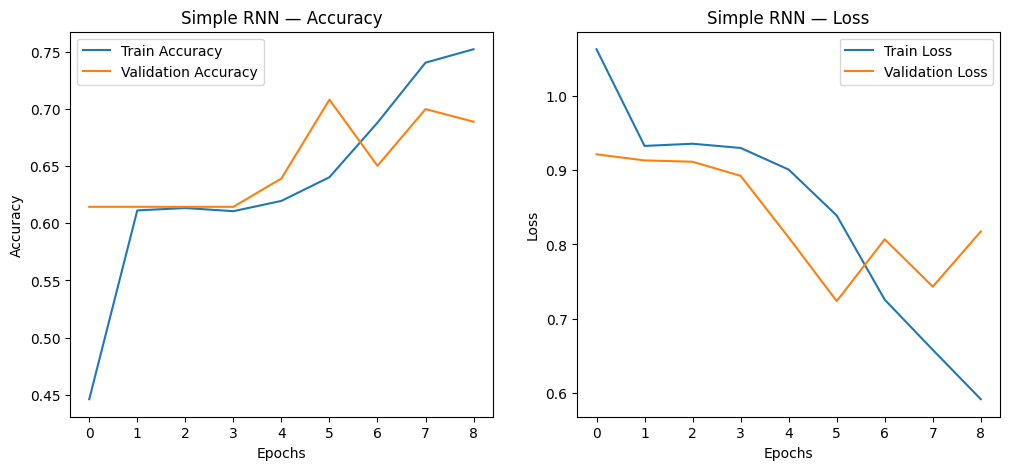

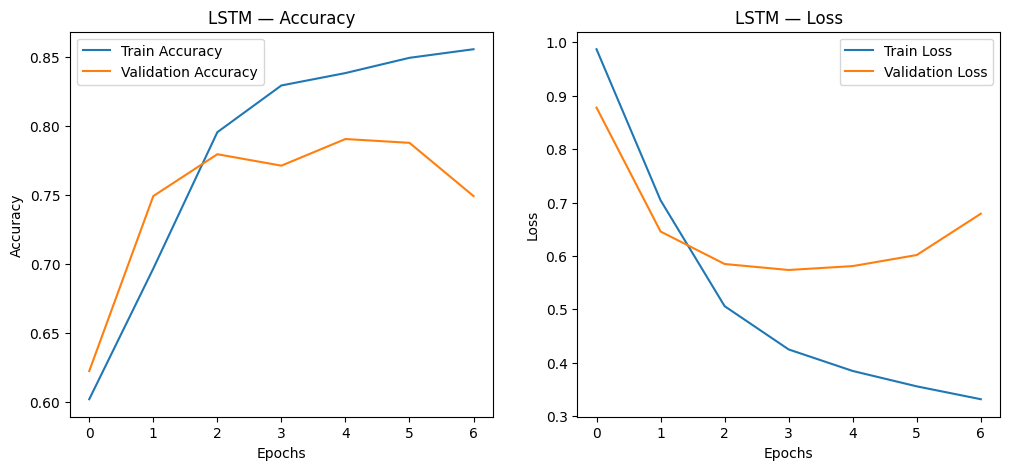

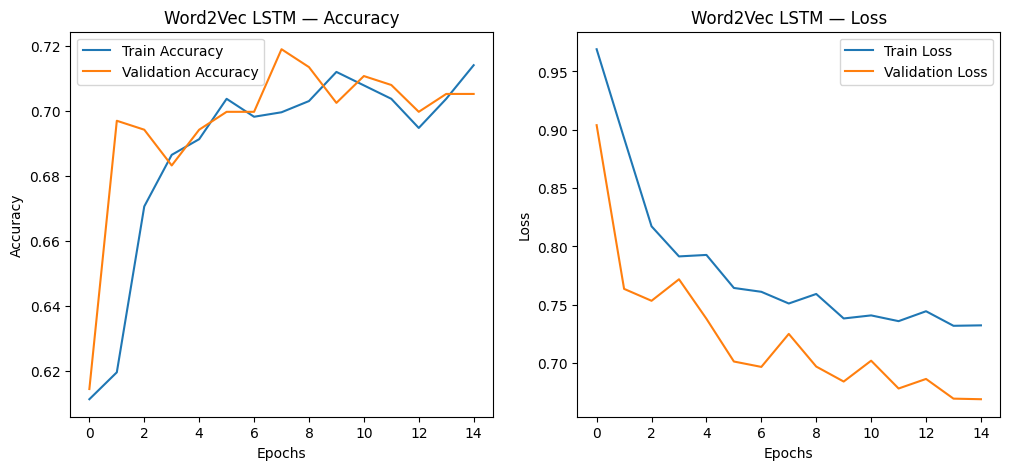

In [23]:
from IPython.display import display

# Display and immediately close each figure to free memory
fig_rnn = plot_history(history_rnn, 'Simple RNN')
display(fig_rnn)
plt.close(fig_rnn)

fig_lstm = plot_history(history_lstm, 'LSTM')
display(fig_lstm)
plt.close(fig_lstm)

fig_w2v = plot_history(history_w2v, 'Word2Vec LSTM')
display(fig_w2v)
plt.close(fig_w2v)

### 6.2 Test Set Evaluation

Each model is evaluated on the **held-out test set** — never seen during training or validation.
The confusion matrix shows which classes are most frequently confused.

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy of Simple RNN: 0.7152

Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.77      0.94      0.85       278
    positive       0.55      0.54      0.55       114

    accuracy                           0.72       453
   macro avg       0.44      0.50      0.47       453
weighted avg       0.61      0.72      0.66       453



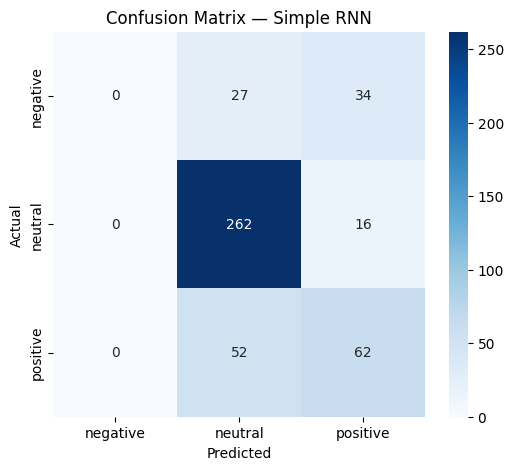

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Accuracy of LSTM: 0.7616

Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.91      0.90      0.91       278
    positive       0.53      0.83      0.65       114

    accuracy                           0.76       453
   macro avg       0.48      0.58      0.52       453
weighted avg       0.69      0.76      0.72       453



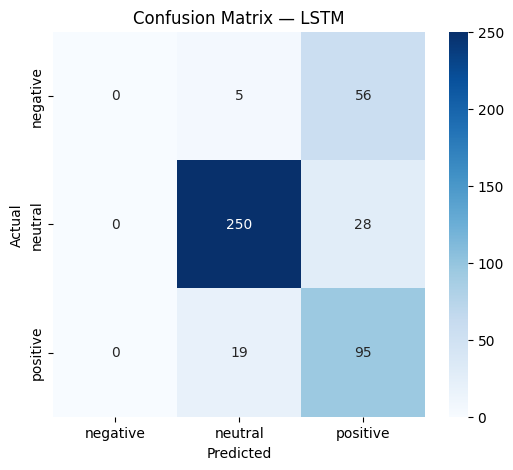

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Accuracy of Word2Vec LSTM: 0.7285

Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.83      0.91      0.87       278
    positive       0.52      0.67      0.58       114

    accuracy                           0.73       453
   macro avg       0.45      0.53      0.48       453
weighted avg       0.64      0.73      0.68       453



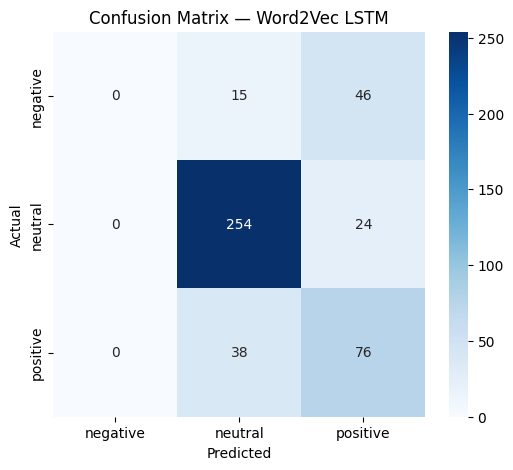

In [24]:
def evaluate_model(model, X_test_pad, y_test, model_name):
    """Print accuracy, full classification report, and a confusion matrix heatmap."""

    # Predict class probabilities, then take argmax for the final label
    predictions = model.predict(X_test_pad)
    y_pred = np.argmax(predictions, axis=1)

    # Overall accuracy on the test set
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {model_name}: {accuracy:.4f}')

    # Per-class precision, recall, F1-score
    print('\nClassification Report:\n')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return y_pred


pred_rnn  = evaluate_model(model_rnn,  X_test_pad, y_test, 'Simple RNN')
pred_lstm = evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM')
pred_w2v  = evaluate_model(model_w2v,  X_test_pad, y_test, 'Word2Vec LSTM')

### 6.3 Model Comparison

           Model  Accuracy
0     Simple RNN  0.715232
1           LSTM  0.761589
2  Word2Vec LSTM  0.728477


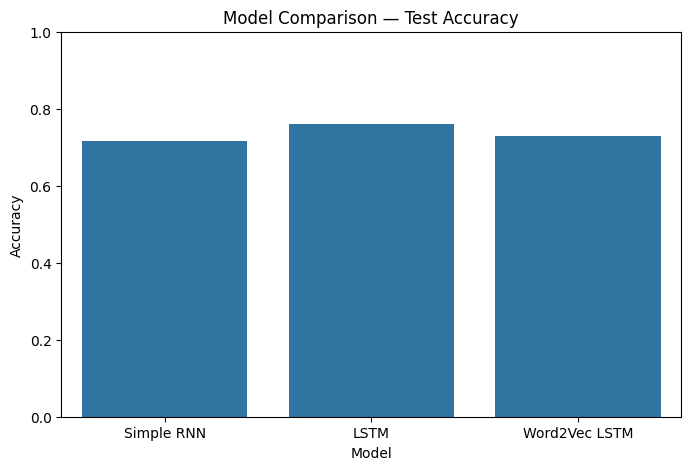

In [25]:
# Collect test accuracy for all three models
results = {
    'Model': ['Simple RNN', 'LSTM', 'Word2Vec LSTM'],
    'Accuracy': [
        accuracy_score(y_test, pred_rnn),
        accuracy_score(y_test, pred_lstm),
        accuracy_score(y_test, pred_w2v)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Comparison — Test Accuracy')
plt.ylim(0, 1)
plt.show()

### 6.4 Inspect Misclassified Examples

Looking at misclassified samples helps identify patterns the model struggles with
(e.g. domain-specific jargon, ambiguous phrasing).

In [26]:
# Use the Word2Vec LSTM (typically best-performing) to find misclassified test samples
predictions = np.argmax(model_w2v.predict(X_test_pad), axis=1)
misclassified_indices = np.where(predictions != y_test)[0]

# Print the first 3 misclassified examples for inspection
for idx in misclassified_indices[:3]:
    print('Original Text:')
    print(X_test.iloc[idx])
    print('\nActual Label   :', label_encoder.inverse_transform([y_test.iloc[idx]])[0])
    print('Predicted Label:', label_encoder.inverse_transform([predictions[idx]])[0])
    print('\n' + '-' * 80 + '\n')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Original Text:
september alone market declined percent yearonyear million liter

Actual Label   : negative
Predicted Label: neutral

--------------------------------------------------------------------------------

Original Text:
major order india comptel corporation received significant longterm order mediation provisioning solution used leading operator india

Actual Label   : positive
Predicted Label: neutral

--------------------------------------------------------------------------------

Original Text:
figure includes change fair value property portfolio eur million

Actual Label   : neutral
Predicted Label: positive

--------------------------------------------------------------------------------



---

## 7. Real-Time Prediction — Gradio GUI

The Gradio interface lets you type any financial sentence and get an instant
sentiment prediction from either the Simple RNN or LSTM model.

The input text passes through the **same preprocessing pipeline** (`clean_text`)
used during training before being fed to the selected model.

Output field :  Description

Predicted Sentiment : positive / neutral / negative

Confidence Score : probability of the predicted class

Cleaned Text : text after preprocessing (for debugging)

In [28]:
import gradio as gr


def predict_sentiment(text, model_name):
    """
    End-to-end prediction pipeline:
      raw text → clean → tokenize → pad → model → label + confidence
    """

    # Step 1: Apply the same cleaning pipeline used during training
    cleaned = clean_text(text)

    # Guard: if nothing remains after cleaning, return early
    if not cleaned.strip():
        return 'N/A', 'N/A', 'Empty or irrelevant text after cleaning.'

    # Step 2: Convert cleaned text to a token ID sequence
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad to max_length (same value used during training)
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Step 4: Select the model based on user's radio button choice
    if model_name == 'Simple RNN':
        model = model_rnn
    elif model_name == 'LSTM':
        model = model_lstm
    elif model_name == 'Word2Vec LSTM':
        model = model_w2v
    else:
        return 'Error', 'N/A', 'Unknown model selected.'

    # Step 5: Get class probabilities from the model (shape: [1, 3])
    probs = model.predict(padded, verbose=0)[0]  # [0] to get the 1-D array

    # Step 6: Identify the class with the highest probability
    predicted_index = int(np.argmax(probs))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    confidence      = f'{probs[predicted_index] * 100:.2f}%'

    return predicted_label, confidence, cleaned


# ── Build the Gradio UI ──────────────────────────────────────────────────────
with gr.Blocks(title='Financial Sentiment Analyser') as demo:

    gr.Markdown("""
    # Financial Sentiment Analyser
    Enter any financial news sentence and select a model to predict its sentiment.
    """)

    with gr.Row():

        # ── Left column: inputs ──────────────────────────────────────────────
        with gr.Column():
            text_input = gr.Textbox(
                label='Enter Financial Text',
                placeholder='e.g. The company reported record profits this quarter...',
                lines=3
            )
            model_choice = gr.Radio(
                choices=['Simple RNN', 'LSTM', 'Word2Vec LSTM'],
                value='LSTM',
                label='Select Model'
            )
            predict_btn = gr.Button('Predict Sentiment', variant='primary')

        # ── Right column: outputs ────────────────────────────────────────────
        with gr.Column():
            sentiment_out   = gr.Textbox(label='Predicted Sentiment')
            confidence_out  = gr.Textbox(label='Confidence Score')
            cleaned_out     = gr.Textbox(label='Cleaned Text (after preprocessing)')

    # ── Example financial sentences ──────────────────────────────────────────
    gr.Markdown('### Try these example sentences:')
    gr.Examples(
        examples=[
            ['The company reported record-breaking profits this quarter.',          'LSTM'],
            ['Operating losses widened as revenue fell sharply year-on-year.',     'LSTM'],
            ['Net sales remained flat with no significant change in margins.',     'Simple RNN'],
            ['The firm announced a major acquisition valued at EUR 2 billion.',    'Word2Vec LSTM'],
            ['Shares plunged after the CEO resigned amid accounting fraud claims.','Simple RNN'],
        ],
        inputs=[text_input, model_choice]
    )

    # ── Wire button click to prediction function ─────────────────────────────
    predict_btn.click(
        fn=predict_sentiment,
        inputs=[text_input, model_choice],
        outputs=[sentiment_out, confidence_out, cleaned_out]
    )

# Launch — share=True generates a public link when running in Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fe55348518b62df52.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
